<a href="https://colab.research.google.com/github/nehansa2003/Weather-Forecasting-and-Analysis-Using-LSTM/blob/main/notebooks/7_geographycal_point_wise_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import os

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_PATH = ('/content/drive/MyDrive/Capstone_Datasets/colombo_weather.parquet')
POINTS_FILE = "/content/drive/MyDrive/Capstone_Datasets/colombo_geographical_points.csv"

LSTM_PREDICTIONS_FILE = "/content/drive/MyDrive/Capstone_Datasets/LSTM_test_predictions_2025.npy"

RAIN_PREDICTIONS_FILE = "/content/drive/MyDrive/Capstone_Datasets/Final_Rainfall_Predictions/RF_LGBM_final_rainfall_predictions_2025.csv"

In [ ]:
weather_df = pd.read_parquet(DATA_PATH)

print("Weather data shape:", weather_df.shape)
print(weather_df.columns.tolist())


Weather data shape: (578688, 34)
['district', 'pointid', 'global_pointid', 'latitude', 'longitude', 'elevation_m', 'datetime', 'date', 'day', 'month', 'year', 'time', 'season', 'hour', 'day_of_week', 'day_of_year', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'temperature_c', 'feelslike_c', 'humidity_pct', 'dewpoint_c', 'pressure_hpa', 'windspeed_kmh', 'winddirection_deg', 'winddirection_compass', 'windgust_kmh', 'rainfall_mm', 'cloudcover_pct', 'solarradiation_wm2', 'sunshineduration_s']


In [ ]:
weather_df["datetime"] = pd.to_datetime(
    weather_df["datetime"]
)

In [ ]:
points_df=pd.read_csv(POINTS_FILE)

In [ ]:
rain_df=pd.read_csv(RAIN_PREDICTIONS_FILE)

In [ ]:
lstm_array = np.load(LSTM_PREDICTIONS_FILE)

In [ ]:
print("Geographical points file:")

print("Shape:", points_df.shape)
print("Columns:")
print(points_df.columns.tolist())

display(points_df.head())

Geographical points file:
Shape: (11, 5)
Columns:
['district', 'pointid', 'latitude', 'longitude', 'elevation_m']


,district,pointid,latitude,longitude,elevation_m
0,Colombo,1,6.85991,79.79351,0.0
1,Colombo,2,6.85991,79.86120,5.0
2,Colombo,3,6.85991,79.92889,19.0
3,Colombo,4,6.92710,79.72583,0.0
4,Colombo,5,6.92710,79.79351,0.0


In [ ]:
print("LSTM prediction type:", type(lstm_array))
print("Shape:", lstm_array.shape)
print("Data type:", lstm_array.dtype)

print("\nFirst 5 predictions:")
print(lstm_array[:5])

LSTM prediction type: <class 'numpy.ndarray'>
Shape: (96096, 9)
Data type: float32

First 5 predictions:
[[ 2.39596119e+01  9.07358932e+01  1.01026801e+03  1.50763626e+01
   2.90692113e-02  3.03304863e+01  9.28520584e+01 -1.46230602e+01
   2.23392601e+01]
 [ 2.38576317e+01  9.09689407e+01  1.00955206e+03  1.38034916e+01
   6.79976344e-02  2.83437748e+01  9.34679794e+01 -1.09832897e+01
   2.23244305e+01]
 [ 2.39503098e+01  9.03441391e+01  1.00887976e+03  1.52076054e+01
   1.24348387e-01  3.09731922e+01  9.56662140e+01 -1.17642651e+01
   2.23427563e+01]
 [ 2.39008675e+01  8.98213882e+01  1.00869635e+03  1.56616344e+01
   8.52403790e-02  3.18506584e+01  9.56532516e+01 -9.37898064e+00
   2.22177677e+01]
 [ 2.39496632e+01  8.92444305e+01  1.00848297e+03  1.67292957e+01
   4.35057245e-02  3.36951103e+01  9.50799713e+01 -7.57056952e+00
   2.21858253e+01]]


In [ ]:
print("Rainfall prediction file")

print("Shape:", rain_df.shape)
print("Columns:")
print(rain_df.columns.tolist())

display(rain_df.head())

Rainfall prediction file
Shape: (96096, 10)
Columns:
['district', 'pointid', 'latitude', 'longitude', 'datetime', 'rainfall_mm', 'rain_occurs', 'predicted_rain_occurs', 'rain_probability', 'predicted_rainfall_mm']


,district,pointid,latitude,longitude,datetime,rainfall_mm,rain_occurs,predicted_rain_occurs,rain_probability,predicted_rainfall_mm
0,Colombo,1,6.85991,79.79351,2025-01-02 00:00:00,0.3,1,0,0.159348,0.000000
1,Colombo,1,6.85991,79.79351,2025-01-02 01:00:00,0.1,1,1,0.727897,0.683686
2,Colombo,1,6.85991,79.79351,2025-01-02 02:00:00,0.0,0,1,0.665244,0.605465
3,Colombo,1,6.85991,79.79351,2025-01-02 03:00:00,0.0,0,0,0.266801,0.000000
4,Colombo,1,6.85991,79.79351,2025-01-02 04:00:00,0.0,0,0,0.292216,0.000000


In [ ]:
print("NaN values:", np.isnan(lstm_array).sum())
print("Inf values:", np.isinf(lstm_array).sum())

NaN values: 0
Inf values: 0


In [ ]:
for i in range(lstm_array.shape[1]):
    print(
        f"Column {i}: "
        f"min={np.nanmin(lstm_array[:, i]):.4f}, "
        f"max={np.nanmax(lstm_array[:, i]):.4f}, "
        f"mean={np.nanmean(lstm_array[:, i]):.4f}"
    )

Column 0: min=20.6790, max=34.1285, mean=26.8530
Column 1: min=32.7217, max=100.7364, mean=82.8559
Column 2: min=1004.4755, max=1014.9664, mean=1009.7495
Column 3: min=1.8031, max=50.0829, mean=11.0925
Column 4: min=-0.2006, max=13.0250, mean=0.2885
Column 5: min=3.1610, max=89.8608, mean=24.0850
Column 6: min=-3.3180, max=111.7585, mean=77.6467
Column 7: min=-70.1813, max=1002.4693, mean=223.2280
Column 8: min=16.4192, max=26.0222, mean=23.5319


In [ ]:
lstm_df = pd.DataFrame(
    lstm_array,
    columns=[
        "temperature",
        "humidity",
        "pressure",
        "windspeed",
        "rainfall",
        "windgust",
        "cloud",
        "solar",
        "dewpoint"
    ]
)

print("Shape:", lstm_df.shape)
display(lstm_df.head())

Shape: (96096, 9)


,temperature,humidity,pressure,windspeed,rainfall,windgust,cloud,solar,dewpoint
0,23.959612,90.735893,1010.268005,15.076363,0.029069,30.330486,92.852058,-14.623060,22.339260
1,23.857632,90.968941,1009.552063,13.803492,0.067998,28.343775,93.467979,-10.983290,22.324430
2,23.950310,90.344139,1008.879761,15.207605,0.124348,30.973192,95.666214,-11.764265,22.342756
3,23.900867,89.821388,1008.696350,15.661634,0.085240,31.850658,95.653252,-9.378981,22.217768
4,23.949663,89.244431,1008.482971,16.729296,0.043506,33.695110,95.079971,-7.570570,22.185825


In [ ]:
points_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   district     11 non-null     object 
 1   pointid      11 non-null     int64  
 2   latitude     11 non-null     float64
 3   longitude    11 non-null     float64
 4   elevation_m  11 non-null     float64
dtypes: float64(3), int64(1), object(1)
memory usage: 572.0+ bytes


In [ ]:
points_df.head(10)

,district,pointid,latitude,longitude,elevation_m
0,Colombo,1,6.85991,79.79351,0.0
1,Colombo,2,6.85991,79.86120,5.0
2,Colombo,3,6.85991,79.92889,19.0
3,Colombo,4,6.92710,79.72583,0.0
4,Colombo,5,6.92710,79.79351,0.0
5,Colombo,6,6.92710,79.86120,9.0
6,Colombo,7,6.92710,79.92889,24.0
7,Colombo,8,6.92710,79.99657,8.0
8,Colombo,9,6.99429,79.79351,0.0
9,Colombo,10,6.99429,79.86120,0.0


In [ ]:
lstm_df["pointid"] = rain_df["pointid"].values
lstm_df["datetime"]=rain_df["datetime"].values

In [ ]:
display(lstm_df.head())

,temperature,humidity,pressure,windspeed,rainfall,windgust,cloud,solar,dewpoint,pointid,datetime
0,23.959612,90.735893,1010.268005,15.076363,0.029069,30.330486,92.852058,-14.623060,22.339260,1,2025-01-02 00:00:00
1,23.857632,90.968941,1009.552063,13.803492,0.067998,28.343775,93.467979,-10.983290,22.324430,1,2025-01-02 01:00:00
2,23.950310,90.344139,1008.879761,15.207605,0.124348,30.973192,95.666214,-11.764265,22.342756,1,2025-01-02 02:00:00
3,23.900867,89.821388,1008.696350,15.661634,0.085240,31.850658,95.653252,-9.378981,22.217768,1,2025-01-02 03:00:00
4,23.949663,89.244431,1008.482971,16.729296,0.043506,33.695110,95.079971,-7.570570,22.185825,1,2025-01-02 04:00:00


In [ ]:
print("Number of geographical points:", points_df["pointid"].nunique())
print("LSTM points:", lstm_df["pointid"].nunique())
print("Rainfall model points:", rain_df["pointid"].nunique())

Number of geographical points: 11
LSTM points: 11
Rainfall model points: 11


2025 actual observations

In [ ]:
weather_2025 = weather_df[
    weather_df["datetime"].dt.year == 2025
].copy()

print("2025 weather data shape:", weather_2025.shape)

2025 weather data shape: (96360, 34)


In [ ]:
print("Start:", weather_2025["datetime"].min())
print("End:", weather_2025["datetime"].max())

Start: 2025-01-01 00:00:00
End: 2025-12-31 23:00:00


In [ ]:
print(
    "Number of points:",
    weather_2025["pointid"].nunique()
)

print(
    "Point IDs:",
    sorted(weather_2025["pointid"].unique())[:20]
)

Number of points: 11
Point IDs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]


In [ ]:
# LSTM prediction columns
lstm_variables = {
    "temperature": ("temperature_2m", "pred_temperature"),
    "humidity": ("relative_humidity_2m", "pred_humidity"),
    "pressure": ("pressure_msl", "pred_pressure"),
    "windspeed": ("wind_speed_10m", "pred_windspeed"),
    "windgust": ("wind_gusts_10m", "pred_windgust"),
    "cloud": ("cloud_cover", "pred_cloud"),
    "solar": ("shortwave_radiation", "pred_solar"),
    "dewpoint": ("dew_point_2m", "pred_dewpoint")
}

# Rainfall model columns
rainfall_actual = "rain"
rainfall_predicted = "predicted_rainfall_mm"

In [ ]:
lstm_df = pd.DataFrame(
    lstm_array,
    columns=[
        "pred_temperature",
        "pred_humidity",
        "pred_pressure",
        "pred_windspeed",
        "pred_rainfall_UNUSED",
        "pred_windgust",
        "pred_cloud",
        "pred_solar",
        "pred_dewpoint"
    ]
)

# Remove LSTM rainfall prediction
lstm_df = lstm_df.drop(columns=["pred_rainfall_UNUSED"])

print(lstm_df.head())
print("LSTM rows:", len(lstm_df))

   pred_temperature  pred_humidity  pred_pressure  pred_windspeed  \
0         23.959612      90.735893    1010.268005       15.076363   
1         23.857632      90.968941    1009.552063       13.803492   
2         23.950310      90.344139    1008.879761       15.207605   
3         23.900867      89.821388    1008.696350       15.661634   
4         23.949663      89.244431    1008.482971       16.729296   

   pred_windgust  pred_cloud  pred_solar  pred_dewpoint  
0      30.330486   92.852058  -14.623060      22.339260  
1      28.343775   93.467979  -10.983290      22.324430  
2      30.973192   95.666214  -11.764265      22.342756  
3      31.850658   95.653252   -9.378981      22.217768  
4      33.695110   95.079971   -7.570570      22.185825  
LSTM rows: 96096


In [ ]:
metadata = rain_df[
    [
        "district",
        "pointid",
        "latitude",
        "longitude",
        "datetime"
    ]
].copy()

metadata["datetime"] = pd.to_datetime(metadata["datetime"])

print("Metadata rows:", len(metadata))
print(metadata.head())

Metadata rows: 96096
  district  pointid  latitude  longitude            datetime
0  Colombo        1   6.85991   79.79351 2025-01-02 00:00:00
1  Colombo        1   6.85991   79.79351 2025-01-02 01:00:00
2  Colombo        1   6.85991   79.79351 2025-01-02 02:00:00
3  Colombo        1   6.85991   79.79351 2025-01-02 03:00:00
4  Colombo        1   6.85991   79.79351 2025-01-02 04:00:00


In [ ]:
print("LSTM predictions:", len(lstm_df))
print("Metadata:", len(metadata))

assert len(lstm_df) == len(metadata), \
    "ERROR: LSTM predictions and metadata have different numbers of rows!"

LSTM predictions: 96096
Metadata: 96096


In [ ]:
lstm_predictions = pd.concat(
    [
        metadata.reset_index(drop=True),
        lstm_df.reset_index(drop=True)
    ],
    axis=1
)

print(lstm_predictions.head())

  district  pointid  latitude  longitude            datetime  \
0  Colombo        1   6.85991   79.79351 2025-01-02 00:00:00   
1  Colombo        1   6.85991   79.79351 2025-01-02 01:00:00   
2  Colombo        1   6.85991   79.79351 2025-01-02 02:00:00   
3  Colombo        1   6.85991   79.79351 2025-01-02 03:00:00   
4  Colombo        1   6.85991   79.79351 2025-01-02 04:00:00   

   pred_temperature  pred_humidity  pred_pressure  pred_windspeed  \
0         23.959612      90.735893    1010.268005       15.076363   
1         23.857632      90.968941    1009.552063       13.803492   
2         23.950310      90.344139    1008.879761       15.207605   
3         23.900867      89.821388    1008.696350       15.661634   
4         23.949663      89.244431    1008.482971       16.729296   

   pred_windgust  pred_cloud  pred_solar  pred_dewpoint  
0      30.330486   92.852058  -14.623060      22.339260  
1      28.343775   93.467979  -10.983290      22.324430  
2      30.973192   95.6662

Actual weather variables

In [ ]:
actual_2025 = weather_2025[
    [
        "pointid",
        "datetime",
        "temperature_c",
    "humidity_pct",
    "pressure_hpa",
    "windspeed_kmh",
    "windgust_kmh",
    "cloudcover_pct",
    "solarradiation_wm2",
    "dewpoint_c",
    ]
].copy()

actual_2025 = actual_2025.rename(
    columns={
        "temperature_c": "actual_temperature",
        "humidity_pct": "actual_humidity",
        "pressure_hpa": "actual_pressure",
        "windspeed_kmh": "actual_windspeed",
        "windgust_kmh": "actual_windgust",
        "cloudcover_pct": "actual_cloud",
        "solarradiation_wm2": "actual_solar",
        "dewpoint_c": "actual_dewpoint"
    }
)

print(actual_2025.head())

       pointid            datetime  actual_temperature  actual_humidity  \
43848        1 2025-01-01 00:00:00                24.2               92   
43849        1 2025-01-01 01:00:00                23.9               93   
43850        1 2025-01-01 02:00:00                23.7               93   
43851        1 2025-01-01 03:00:00                23.5               94   
43852        1 2025-01-01 04:00:00                23.5               94   

       actual_pressure  actual_windspeed  actual_windgust  actual_cloud  \
43848           1010.9               9.0             18.4           100   
43849           1009.9               9.6             24.5           100   
43850           1009.3              11.5             23.4           100   
43851           1008.7              10.7             24.5           100   
43852           1008.6               7.8             22.0           100   

       actual_solar  actual_dewpoint  
43848           0.0             22.7  
43849           0.0 

In [ ]:
lstm_evaluation = lstm_predictions.merge(
    actual_2025,
    on=["pointid", "datetime"],
    how="inner"
)

print("LSTM predictions:", len(lstm_predictions))
print("Matched observations:", len(lstm_evaluation))

LSTM predictions: 96096
Matched observations: 96096


In [ ]:
lstm_evaluation.isna().sum()

,0
district,0
pointid,0
latitude,0
longitude,0
datetime,0
pred_temperature,0
pred_humidity,0
pred_pressure,0
pred_windspeed,0
pred_windgust,0


In [ ]:
def calculate_metrics(group, actual_col, predicted_col):

    data = group[[actual_col, predicted_col]].dropna()

    if len(data) == 0:
        return pd.Series({
            "MAE": np.nan,
            "RMSE": np.nan,
            "R2": np.nan,
            "N": 0
        })

    y_true = data[actual_col].values
    y_pred = data[predicted_col].values

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    if len(np.unique(y_true)) > 1:
        r2 = r2_score(y_true, y_pred)
    else:
        r2 = np.nan

    return pd.Series({
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "N": len(data)
    })

In [ ]:
point_info = (
    lstm_evaluation[
        [
            "district",
            "pointid",
            "latitude",
            "longitude"
        ]
    ]
    .drop_duplicates("pointid")
    .sort_values("pointid")
    .reset_index(drop=True)
)

pointwise_results = point_info.copy()

In [ ]:
for variable, (actual_col, predicted_col) in {
    "temperature": ("actual_temperature", "pred_temperature"),
    "humidity": ("actual_humidity", "pred_humidity"),
    "pressure": ("actual_pressure", "pred_pressure"),
    "windspeed": ("actual_windspeed", "pred_windspeed"),
    "windgust": ("actual_windgust", "pred_windgust"),
    "cloud": ("actual_cloud", "pred_cloud"),
    "solar": ("actual_solar", "pred_solar"),
    "dewpoint": ("actual_dewpoint", "pred_dewpoint")
}.items():

    metrics = (
        lstm_evaluation
        .groupby("pointid")
        .apply(
            lambda group: calculate_metrics(
                group,
                actual_col,
                predicted_col
            ),
            include_groups=False
        )
        .reset_index()
    )

    metrics = metrics.rename(
        columns={
            "MAE": f"{variable}_MAE",
            "RMSE": f"{variable}_RMSE",
            "R2": f"{variable}_R2",
            "N": f"{variable}_N"
        }
    )

    pointwise_results = pointwise_results.merge(
        metrics,
        on="pointid",
        how="left"
    )

Rainfall model evaluation

In [ ]:
rainfall_metrics = []

for point_id, group in rain_df.groupby("pointid"):

    # Actual and predicted rainfall amount
    data = group[
        ["rainfall_mm", "predicted_rainfall_mm"]
    ].dropna()

    if len(data) > 0:

        y_true = data["rainfall_mm"].values
        y_pred = data["predicted_rainfall_mm"].values

        # MAE
        mae = mean_absolute_error(
            y_true,
            y_pred
        )

        # RMSE
        rmse = np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        )

        # R²
        if len(np.unique(y_true)) > 1:
            r2 = r2_score(
                y_true,
                y_pred
            )
        else:
            r2 = np.nan

        rainfall_metrics.append({
            "pointid": point_id,
            "rainfall_MAE": mae,
            "rainfall_RMSE": rmse,
            "rainfall_R2": r2,
            "rainfall_N": len(data)
        })

rainfall_metrics = pd.DataFrame(rainfall_metrics)

display(rainfall_metrics)

,pointid,rainfall_MAE,rainfall_RMSE,rainfall_R2,rainfall_N
0,1,0.260474,0.676243,0.575317,8736
1,2,0.266320,0.669243,0.568225,8736
2,3,0.266556,0.671727,0.565014,8736
3,4,0.250017,0.716662,0.501148,8736
4,5,0.260474,0.676243,0.575317,8736
5,6,0.260724,0.676513,0.574978,8736
6,7,0.260493,0.676232,0.575330,8736
7,8,0.329043,0.891053,0.487696,8736
8,9,0.263042,0.681586,0.572393,8736
9,10,0.263414,0.680704,0.573498,8736


Combine rainfall with the LSTM evaluation

In [ ]:
pointwise_results = pointwise_results.merge(
    rainfall_metrics,
    on="pointid",
    how="left"
)

pointwise_results = pointwise_results.sort_values(
    "pointid"
).reset_index(drop=True)

In [ ]:
print(
    "Final evaluation table shape:",
    pointwise_results.shape
)

display(pointwise_results)

Final evaluation table shape: (11, 40)


,district,pointid,latitude,longitude,temperature_MAE,temperature_RMSE,temperature_R2,temperature_N,humidity_MAE,humidity_RMSE,...,solar_R2,solar_N,dewpoint_MAE,dewpoint_RMSE,dewpoint_R2,dewpoint_N,rainfall_MAE,rainfall_RMSE,rainfall_R2,rainfall_N
0,Colombo,1,6.85991,79.79351,0.330317,0.473443,0.952383,8736.0,1.887476,2.608293,...,0.968773,8736.0,0.281580,0.397666,0.892796,8736.0,0.260474,0.676243,0.575317,8736
1,Colombo,2,6.85991,79.86120,0.332339,0.466422,0.951014,8736.0,1.888950,2.564240,...,0.966624,8736.0,0.278107,0.386074,0.884004,8736.0,0.266320,0.669243,0.568225,8736
2,Colombo,3,6.85991,79.92889,0.333549,0.467111,0.950869,8736.0,1.894147,2.569424,...,0.966490,8736.0,0.277837,0.385298,0.884470,8736.0,0.266556,0.671727,0.565014,8736
3,Colombo,4,6.92710,79.72583,0.358105,0.487517,0.815559,8736.0,2.093216,2.780135,...,0.966004,8736.0,0.256147,0.346786,0.837468,8736.0,0.250017,0.716662,0.501148,8736
4,Colombo,5,6.92710,79.79351,0.330317,0.473443,0.952383,8736.0,1.887476,2.608293,...,0.968773,8736.0,0.281580,0.397666,0.892796,8736.0,0.260474,0.676243,0.575317,8736
5,Colombo,6,6.92710,79.86120,0.329526,0.472716,0.952520,8736.0,1.883471,2.604697,...,0.968870,8736.0,0.281192,0.397690,0.892846,8736.0,0.260724,0.676513,0.574978,8736
6,Colombo,7,6.92710,79.92889,0.330274,0.473411,0.952389,8736.0,1.886923,2.608170,...,0.968772,8736.0,0.281504,0.397607,0.892828,8736.0,0.260493,0.676232,0.575330,8736
7,Colombo,8,6.92710,79.99657,0.378415,0.539445,0.954435,8736.0,2.091378,2.857415,...,0.969486,8736.0,0.287047,0.405271,0.870193,8736.0,0.329043,0.891053,0.487696,8736
8,Colombo,9,6.99429,79.79351,0.327286,0.470362,0.955428,8736.0,1.868176,2.588789,...,0.970118,8736.0,0.277930,0.391941,0.901052,8736.0,0.263042,0.681586,0.572393,8736
9,Colombo,10,6.99429,79.86120,0.326658,0.470433,0.955392,8736.0,1.866271,2.586776,...,0.970151,8736.0,0.278311,0.393374,0.900295,8736.0,0.263414,0.680704,0.573498,8736


Rainfall occurrence confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_true = rain_df["rain_occurs"]
y_pred = rain_df["predicted_rain_occurs"]

cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[45165  9209]
 [ 7382 34340]]


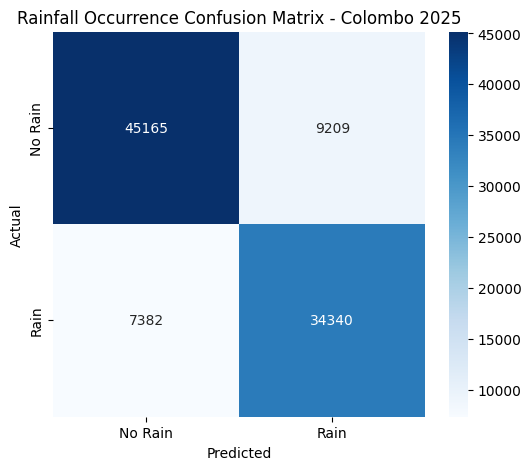

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Rainfall Occurrence Confusion Matrix - Colombo 2025")

plt.show()

In [ ]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 45165
False Positives: 9209
False Negatives: 7382
True Positives : 34340


Rainfall occurrence metrics

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("Rainfall Occurrence Metrics")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Rainfall Occurrence Metrics
Accuracy : 0.8273
Precision: 0.7885
Recall   : 0.8231
F1-score : 0.8054


In [ ]:

# Make a copy
accuracy_results = pointwise_results.copy()

# ------------------------------------------------
# 1. Define the weather variables
# ------------------------------------------------

variables = [
    "temperature",
    "humidity",
    "pressure",
    "windspeed",
    "rainfall",
    "windgust",
    "cloud",
    "solar",
    "dewpoint"
]

# ------------------------------------------------
# 2. Define observed ranges
# ------------------------------------------------
# Replace these values with the actual 2025 ranges
# from your test/actual dataset.

observed_ranges = {
    "temperature": 34.0 - 20.0,
    "humidity": 100.0 - 30.0,
    "pressure": 1020.0 - 990.0,
    "windspeed": 50.0 - 0.0,
    "rainfall": 13.0 - 0.0,
    "windgust": 90.0 - 0.0,
    "cloud": 100.0 - 0.0,
    "solar": 1000.0 - 0.0,
    "dewpoint": 27.0 - 15.0
}

# ------------------------------------------------
# 3. Calculate normalized RMSE
# ------------------------------------------------

nrmse_columns = []

for variable in variables:

    rmse_col = f"{variable}_RMSE"

    nrmse_col = f"{variable}_NRMSE"

    accuracy_results[nrmse_col] = (
        accuracy_results[rmse_col] /
        observed_ranges[variable]
    )

    nrmse_columns.append(nrmse_col)

# ------------------------------------------------
# 4. Calculate Overall Normalized Error
# ------------------------------------------------

accuracy_results["Overall_NRMSE"] = (
    accuracy_results[nrmse_columns]
    .mean(axis=1)
)

# ------------------------------------------------
# 5. Convert error into accuracy index
# ------------------------------------------------

accuracy_results["Overall_Accuracy"] = (
    1 - accuracy_results["Overall_NRMSE"]
) * 100

# Keep values between 0 and 100
accuracy_results["Overall_Accuracy"] = (
    accuracy_results["Overall_Accuracy"]
    .clip(0, 100)
)

# ------------------------------------------------
# 6. Display final result
# ------------------------------------------------

display(
    accuracy_results[
        [
            "district",
            "pointid",
            "latitude",
            "longitude",
            "Overall_NRMSE",
            "Overall_Accuracy"
        ]
    ].round(4)
)

,district,pointid,latitude,longitude,Overall_NRMSE,Overall_Accuracy
0,Colombo,1,6.8599,79.7935,0.0552,94.4845
1,Colombo,2,6.8599,79.8612,0.0544,94.5558
2,Colombo,3,6.8599,79.9289,0.0545,94.5531
3,Colombo,4,6.9271,79.7258,0.0601,93.9879
4,Colombo,5,6.9271,79.7935,0.0552,94.4845
5,Colombo,6,6.9271,79.8612,0.0552,94.4850
6,Colombo,7,6.9271,79.9289,0.0552,94.4846
7,Colombo,8,6.9271,79.9966,0.0564,94.3551
8,Colombo,9,6.9943,79.7935,0.0546,94.5410
9,Colombo,10,6.9943,79.8612,0.0546,94.5403


In [ ]:
# ============================================
# OVERALL R² ACROSS ALL WEATHER VARIABLES
# ============================================

r2_columns = [
    "temperature_R2",
    "humidity_R2",
    "pressure_R2",
    "windspeed_R2",
    "rainfall_R2",
    "windgust_R2",
    "cloud_R2",
    "solar_R2",
    "dewpoint_R2"
]

accuracy_results = pointwise_results.copy()

accuracy_results["Overall_R2"] = (
    accuracy_results[r2_columns].mean(axis=1)
)

accuracy_results["Overall_R2_Percentage"] = (
    accuracy_results["Overall_R2"] * 100
)

display(
    accuracy_results[
        [
            "district",
            "pointid",
            "latitude",
            "longitude",
            "Overall_R2",
            "Overall_R2_Percentage"
        ]
    ].round(4)
)

,district,pointid,latitude,longitude,Overall_R2,Overall_R2_Percentage
0,Colombo,1,6.8599,79.7935,0.8525,85.2504
1,Colombo,2,6.8599,79.8612,0.8518,85.1777
2,Colombo,3,6.8599,79.9289,0.8515,85.1483
3,Colombo,4,6.9271,79.7258,0.7976,79.7633
4,Colombo,5,6.9271,79.7935,0.8525,85.2504
5,Colombo,6,6.9271,79.8612,0.8524,85.2439
6,Colombo,7,6.9271,79.9289,0.8525,85.2511
7,Colombo,8,6.9271,79.9966,0.8338,83.3822
8,Colombo,9,6.9943,79.7935,0.8566,85.6551
9,Colombo,10,6.9943,79.8612,0.8566,85.6558


Visualize the metric for all geographical points

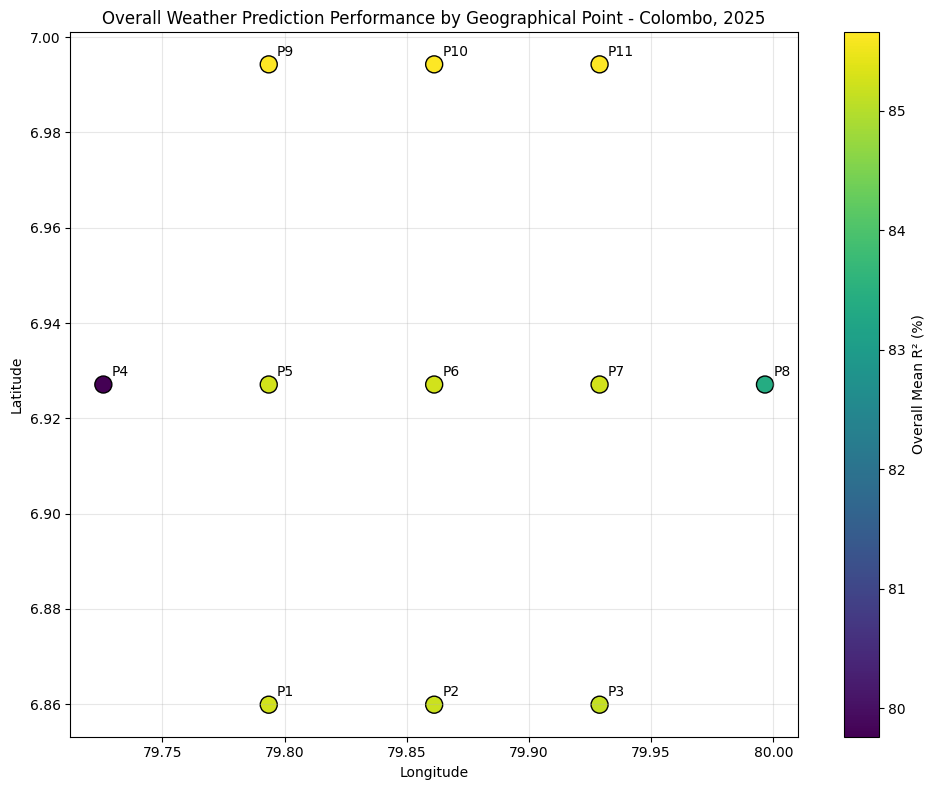

In [ ]:
# ============================================
# GEOGRAPHICAL VISUALIZATION OF OVERALL R²
# ============================================

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    accuracy_results["longitude"],
    accuracy_results["latitude"],
    c=accuracy_results["Overall_R2_Percentage"],
    s=150,
    edgecolor="black"
)

# Add point IDs
for _, row in accuracy_results.iterrows():

    plt.annotate(
        f"P{int(row['pointid'])}",
        (
            row["longitude"],
            row["latitude"]
        ),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=10
    )

plt.colorbar(
    scatter,
    label="Overall Mean R² (%)"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Overall Weather Prediction Performance by Geographical Point - Colombo, 2025"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

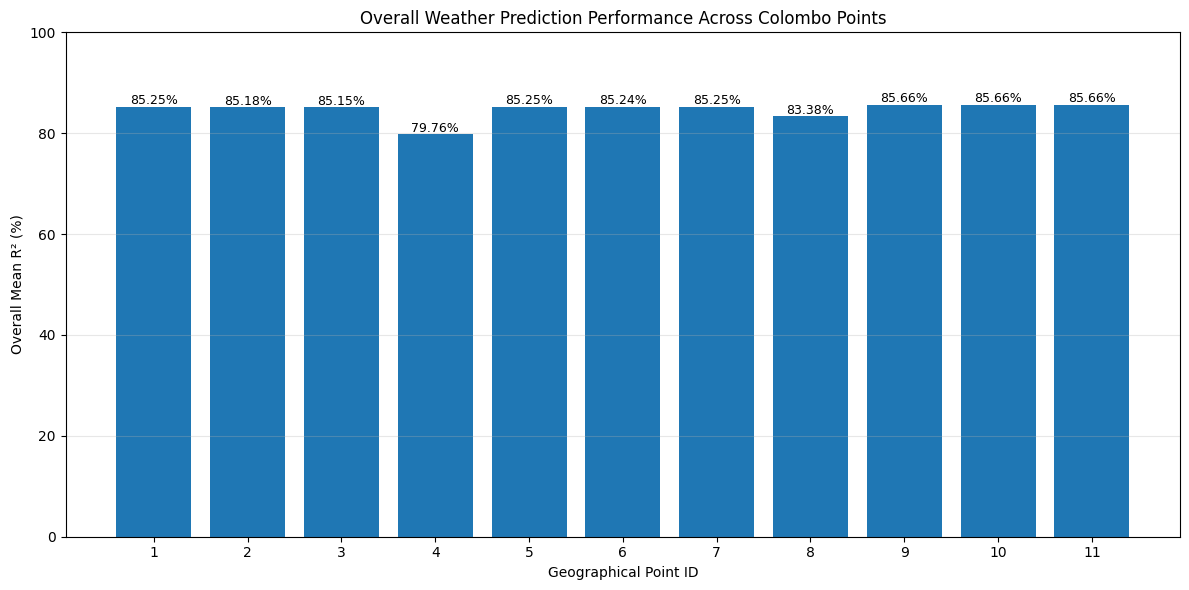

In [ ]:
# ============================================
# BAR CHART
# ============================================

plt.figure(figsize=(12, 6))

bars = plt.bar(
    accuracy_results["pointid"].astype(str),
    accuracy_results["Overall_R2_Percentage"]
)

plt.xlabel("Geographical Point ID")
plt.ylabel("Overall Mean R² (%)")

plt.title(
    "Overall Weather Prediction Performance Across Colombo Points"
)

plt.ylim(0, 100)

# Add values above bars
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center",
        fontsize=9
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
overall_colombo_r2 = (
    accuracy_results["Overall_R2"].mean()
)

overall_colombo_percentage = (
    overall_colombo_r2 * 100
)

print(
    f"Overall Mean R² for Colombo: "
    f"{overall_colombo_r2:.4f}"
)

print(
    f"Overall Performance: "
    f"{overall_colombo_percentage:.2f}%"
)

Overall Mean R² for Colombo: 0.8468
Overall Performance: 84.68%


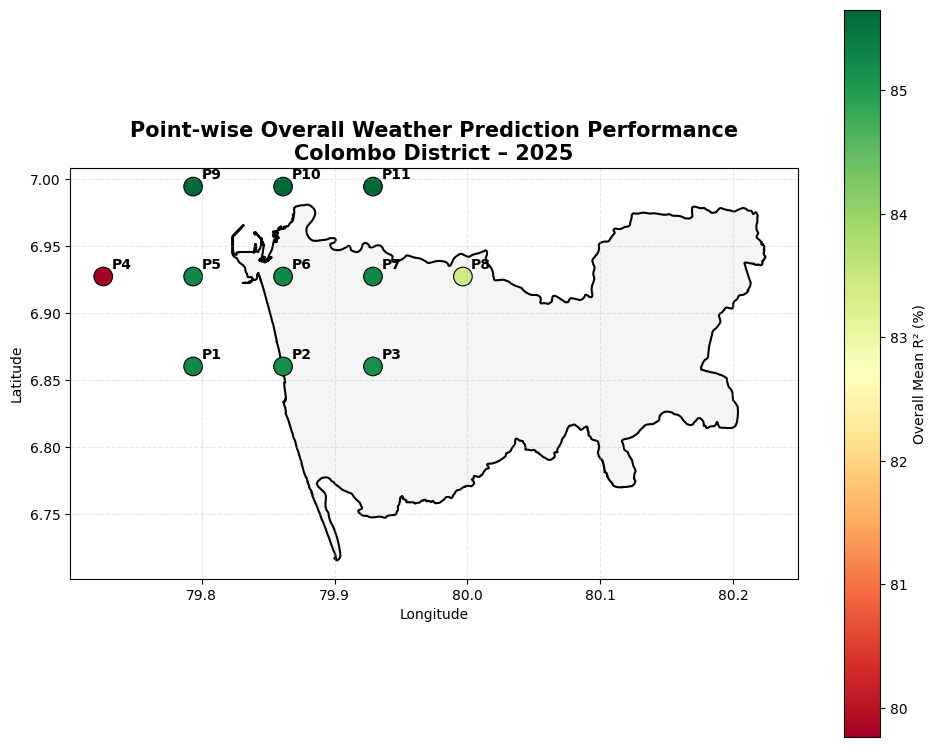

In [ ]:
# ============================================================
# COLOMBO DISTRICT MAP WITH POINT-WISE OVERALL R²
# ============================================================

import geopandas as gpd
import matplotlib.pyplot as plt
import requests
from io import BytesIO

# ------------------------------------------------------------
# 1. Calculate Overall Mean R²
# ------------------------------------------------------------

r2_columns = [
    "temperature_R2",
    "humidity_R2",
    "pressure_R2",
    "windspeed_R2",
    "rainfall_R2",
    "windgust_R2",
    "cloud_R2",
    "solar_R2",
    "dewpoint_R2"
]

accuracy_results = final_results.copy()

accuracy_results["Overall_R2"] = (
    accuracy_results[r2_columns].mean(axis=1)
)

accuracy_results["Overall_R2_Percentage"] = (
    accuracy_results["Overall_R2"] * 100
)

# ------------------------------------------------------------
# 2. Get official Sri Lankan district boundary
# ------------------------------------------------------------

url = (
    "https://gisapps.nsdi.gov.lk/server/rest/services/"
    "Srilanka/Boundaries/MapServer/3/query"
    "?where=district_name%3D%27Colombo%27"
    "&outFields=*"
    "&returnGeometry=true"
    "&f=geojson"
)

response = requests.get(url)
response.raise_for_status()

colombo_geojson = response.json()

# Convert to GeoDataFrame
colombo_map = gpd.GeoDataFrame.from_features(
    colombo_geojson["features"],
    crs="EPSG:4326"
)

# ------------------------------------------------------------
# 3. Convert your prediction points to GeoDataFrame
# ------------------------------------------------------------

points = gpd.GeoDataFrame(
    accuracy_results,
    geometry=gpd.points_from_xy(
        accuracy_results["longitude"],
        accuracy_results["latitude"]
    ),
    crs="EPSG:4326"
)

# ------------------------------------------------------------
# 4. Plot Colombo District map
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 10))

# Colombo district boundary
colombo_map.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="black",
    linewidth=1.5
)

# Weather prediction points
points.plot(
    ax=ax,
    column="Overall_R2_Percentage",
    cmap="RdYlGn",
    markersize=180,
    edgecolor="black",
    linewidth=0.8,
    legend=True,
    legend_kwds={
        "label": "Overall Mean R² (%)",
        "shrink": 0.75
    }
)

# ------------------------------------------------------------
# 5. Add Point IDs
# ------------------------------------------------------------

for _, row in points.iterrows():

    ax.annotate(
        f"P{int(row['pointid'])}",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold"
    )

# ------------------------------------------------------------
# 6. Labels and title
# ------------------------------------------------------------

ax.set_title(
    "Point-wise Overall Weather Prediction Performance\n"
    "Colombo District – 2025",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.grid(
    True,
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.show()